In [1]:
import numpy as np
import pylab as pl
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix,classification_report

In [2]:
train_path = "/kaggle/input/datasets/jpacse/datasets-for-churn-telecom/cell2celltrain.csv"
test_path  = "/kaggle/input/datasets/jpacse/datasets-for-churn-telecom/cell2cellholdout.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Dataset Shape:", train.shape)
print(train.info())

Dataset Shape: (51047, 58)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls  

In [3]:
train['Churn'] = train['Churn'].map({'Yes':1, 'No':0})
train.fillna(0, inplace=True)

train['Churn'].value_counts()

Churn
0    36336
1    14711
Name: count, dtype: int64

In [4]:
train = train.replace(np.nan, 0)

# inplace
train.replace(np.nan, 0, inplace=True)

In [5]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
def FunLabelEncoder(df):
    for c in df.columns:
        if df.dtypes[c] == object:
            le.fit(df[c].astype(str))
            df[c] = le.transform(df[c].astype(str))
    return df

In [6]:
df = FunLabelEncoder(train)
df.info()
df.iloc[235:300,:]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  int64  
 2   MonthlyRevenue             51047 non-null  float64
 3   MonthlyMinutes             51047 non-null  float64
 4   TotalRecurringCharge       51047 non-null  float64
 5   DirectorAssistedCalls      51047 non-null  float64
 6   OverageMinutes             51047 non-null  float64
 7   RoamingCalls               51047 non-null  float64
 8   PercChangeMinutes          51047 non-null  float64
 9   PercChangeRevenues         51047 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
235,3001782,1,64.80,479.0,50.0,0.00,139.0,0.0,-337.0,-13.3,...,0,3,0,0,8,0,0,2,4,2
236,3001786,1,17.14,3.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,0,0,15,0,0,2,3,2
237,3001790,0,124.06,2955.0,82.0,0.00,421.0,0.0,262.0,20.0,...,0,0,0,1,14,0,0,2,3,1
238,3001794,0,80.28,1245.0,68.0,1.24,73.0,0.0,-160.0,-62.1,...,0,6,0,3,0,0,2,0,4,2
239,3001802,0,100.05,820.0,85.0,3.46,0.0,17.5,2.0,-16.1,...,0,8,0,0,0,0,0,0,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,3002250,1,95.30,894.0,52.0,2.48,30.0,28.4,146.0,-10.0,...,0,0,0,0,3,0,2,0,3,1
296,3002258,0,104.29,1005.0,105.0,0.99,2.0,3.7,-145.0,1.9,...,0,0,0,0,8,0,0,0,3,1
297,3002262,0,95.27,815.0,95.0,1.49,0.0,0.0,-350.0,-7.0,...,0,5,0,0,0,0,0,0,3,1
298,3002270,0,79.84,596.0,75.0,1.73,8.0,0.0,-38.0,-0.9,...,0,9,0,0,3,0,0,2,3,2


In [7]:
test = FunLabelEncoder(test)
test.info()
test.iloc[235:300,:]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 20000 non-null  int64  
 1   Churn                      0 non-null      float64
 2   MonthlyRevenue             19940 non-null  float64
 3   MonthlyMinutes             19940 non-null  float64
 4   TotalRecurringCharge       19940 non-null  float64
 5   DirectorAssistedCalls      19940 non-null  float64
 6   OverageMinutes             19940 non-null  float64
 7   RoamingCalls               19940 non-null  float64
 8   PercChangeMinutes          19865 non-null  float64
 9   PercChangeRevenues         19865 non-null  float64
 10  DroppedCalls               20000 non-null  float64
 11  BlockedCalls               20000 non-null  float64
 12  UnansweredCalls            20000 non-null  float64
 13  CustomerCareCalls          20000 non-null  flo

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
235,3004718,NaN,33.10,242.0,40.0,0.00,0.0,0.0,-110.0,-2.7,...,0,4,0,0,8,0,0,2,1,2
236,3004722,NaN,64.69,370.0,40.0,0.25,98.0,0.0,8.0,0.1,...,1,0,0,1,8,0,0,3,3,1
237,3004738,NaN,100.56,660.0,50.0,3.46,151.0,0.0,-390.0,-47.6,...,0,6,0,0,3,0,2,0,3,0
238,3004746,NaN,35.17,308.0,30.0,0.00,14.0,0.0,42.0,10.9,...,1,0,0,1,15,0,0,2,3,2
239,3004762,NaN,30.25,268.0,30.0,0.25,0.0,0.0,48.0,-0.2,...,0,6,0,0,3,0,0,2,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,3005682,NaN,81.49,741.0,75.0,5.69,0.0,0.8,185.0,-1.5,...,0,0,0,0,14,0,0,2,3,1
296,3005710,NaN,30.00,204.0,30.0,0.00,0.0,0.0,43.0,0.0,...,0,0,0,0,8,0,0,0,3,1
297,3005750,NaN,51.21,312.0,35.0,0.25,37.0,0.0,-149.0,-13.0,...,0,6,0,0,2,0,2,0,3,1
298,3005766,NaN,35.72,94.0,30.0,3.46,0.0,0.0,-40.0,-2.8,...,0,7,0,1,8,0,0,2,3,0


In [8]:
test = test.drop(columns=['Churn'], axis=1)
test = test.dropna(how='any')
print(test.shape)

(19533, 57)


In [9]:
train['Churn'].value_counts()

Churn
0    36336
1    14711
Name: count, dtype: int64

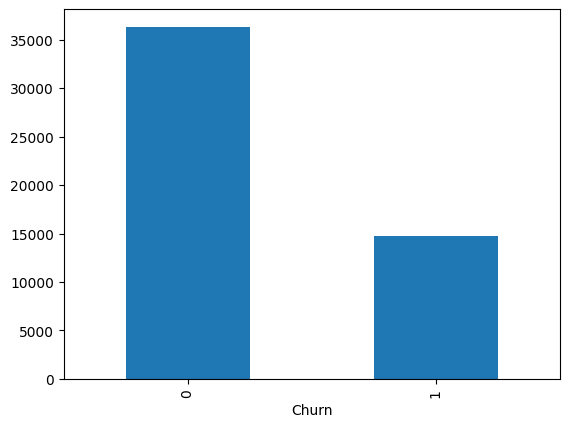

In [10]:
train.Churn.value_counts()[0:30].plot(kind='bar')
plt.show()

<Axes: >

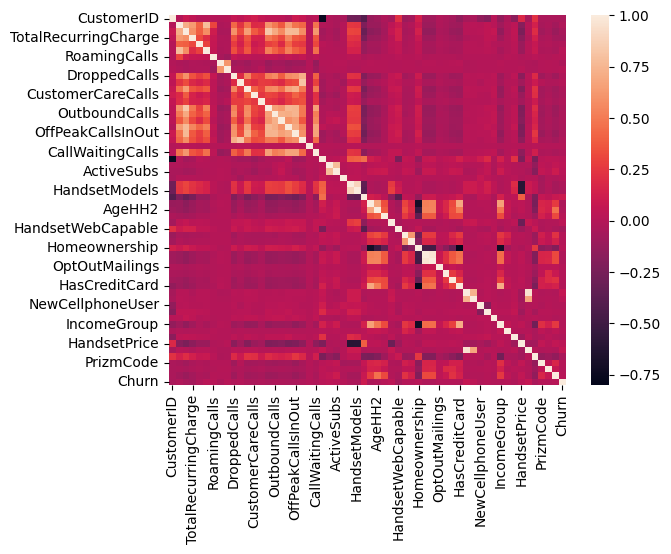

In [11]:
train = train[['CustomerID','MonthlyRevenue','MonthlyMinutes','TotalRecurringCharge','DirectorAssistedCalls','OverageMinutes',
         'RoamingCalls','PercChangeMinutes','PercChangeRevenues','DroppedCalls','BlockedCalls','UnansweredCalls','CustomerCareCalls',
         'ThreewayCalls','ReceivedCalls','OutboundCalls','InboundCalls','PeakCallsInOut','OffPeakCallsInOut','DroppedBlockedCalls','CallForwardingCalls'
         ,'CallWaitingCalls','MonthsInService','UniqueSubs','ActiveSubs','ServiceArea','Handsets','HandsetModels',              
'CurrentEquipmentDays','AgeHH1','AgeHH2','ChildrenInHH','HandsetRefurbished','HandsetWebCapable','TruckOwner','RVOwner','Homeownership','BuysViaMailOrder','RespondsToMailOffers','OptOutMailings',          
'NonUSTravel','OwnsComputer','HasCreditCard','RetentionCalls','RetentionOffersAccepted','NewCellphoneUser',          
'NotNewCellphoneUser','ReferralsMadeBySubscriber','IncomeGroup','OwnsMotorcycle','AdjustmentsToCreditRating', 
'HandsetPrice','MadeCallToRetentionTeam','CreditRating','PrizmCode','Occupation','MaritalStatus','Churn']] #Subsetting the data
cor = train.corr() 
sns.heatmap(cor) 

In [12]:
RANDOM_STATE = 42

from sklearn.model_selection import train_test_split
y = train['Churn']
X = train.drop(columns=['Churn'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

In [13]:
from sklearn.ensemble import RandomForestClassifier

rndforclas = RandomForestClassifier(n_estimators=150,
                                    random_state=42,
                                    n_jobs=2,
                                    )

rndforclas.fit(X_train, y_train)

y_predict_rndforclas = rndforclas.predict(X_test)

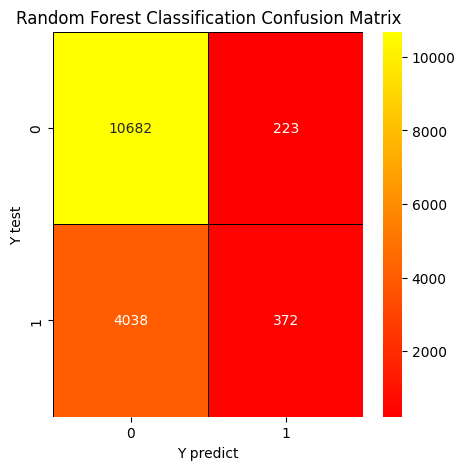

In [14]:
rndforclas_conf = confusion_matrix(y_test, y_predict_rndforclas)
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(rndforclas_conf, annot=True, linewidth=0.7, linecolor='black', fmt='g', ax=ax, cmap="autumn")
plt.title('Random Forest Classification Confusion Matrix')
plt.xlabel('Y predict')
plt.ylabel('Y test')
plt.show()

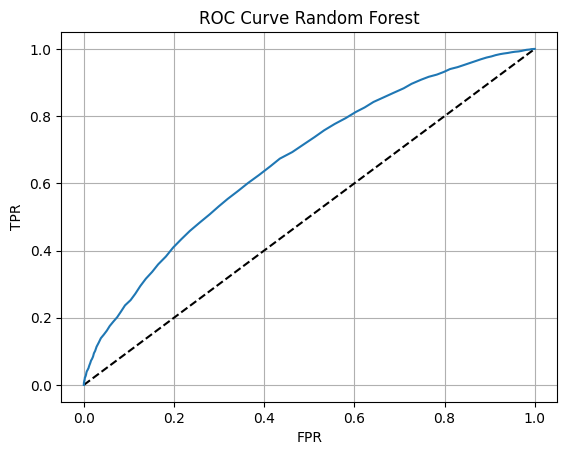

In [15]:
from sklearn.metrics import roc_curve

y_predict_proba = rndforclas.predict_proba(X_test)
y_predict_rndforclas = y_predict_proba[:, 1]  # вероятности для класса 1
fpr, tpr, thresholds = roc_curve(y_test, y_predict_rndforclas)

plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='ANN')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve Random Forest')
plt.grid(True)
plt.show()

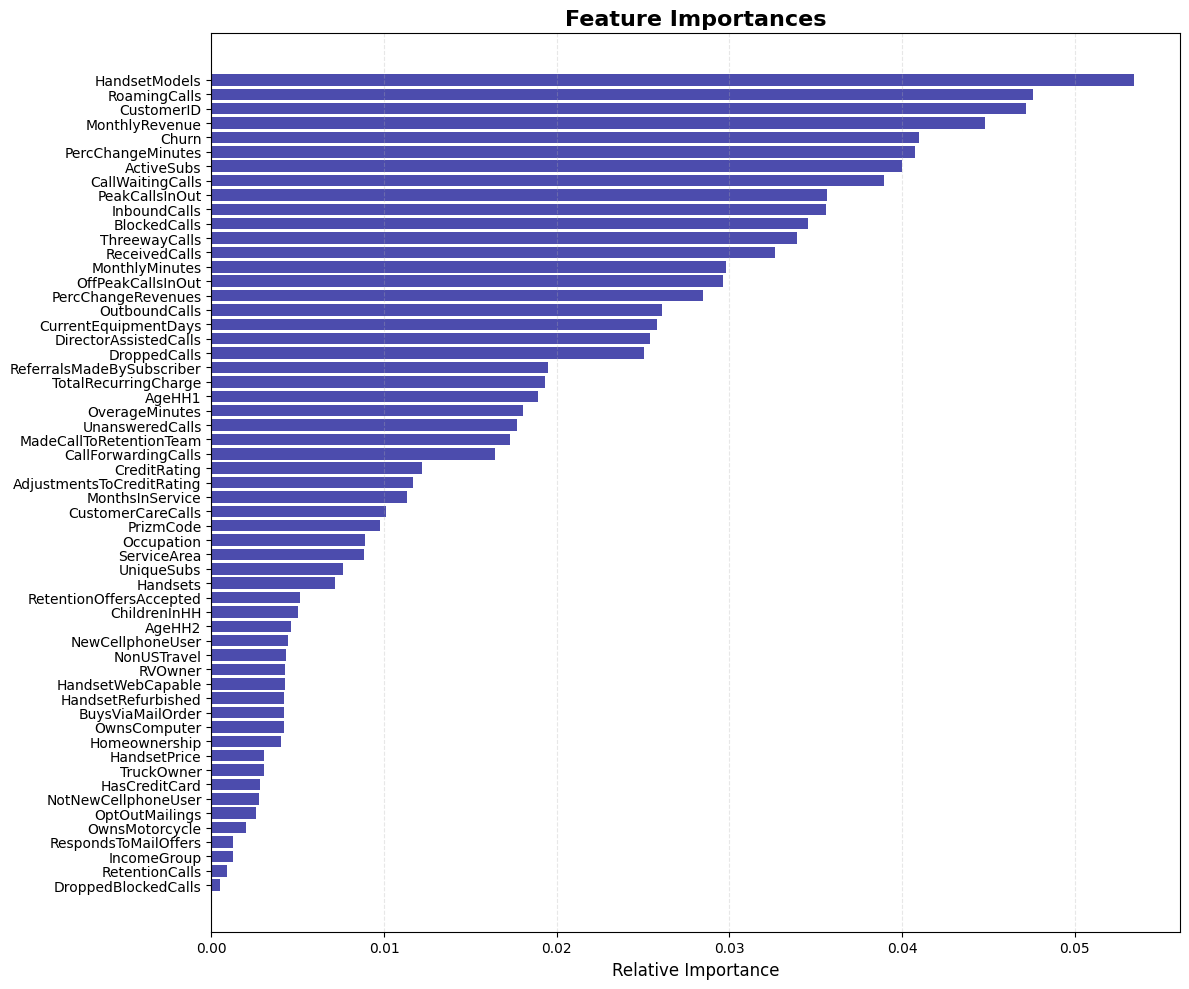

In [16]:
features=df.columns
importances = rndforclas.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 10))
plt.title('Feature Importances', fontsize=16, fontweight='bold')
plt.barh(range(len(indices)), importances[indices], color='darkblue', alpha=0.7, align='center')
plt.yticks(range(len(indices)), features[indices])
plt.xlabel('Relative Importance', fontsize=12)
plt.grid(axis='x', alpha=0.3, linestyle='--')  
plt.tight_layout()
plt.show()